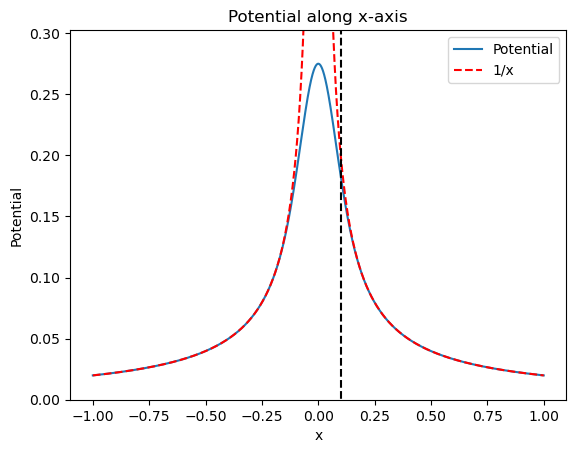

In [1]:
import libPoisson as lb
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
eps = 4.0
solver = lb.NBody(permittivity=eps, charge_radius=0.1)
# Create a charge in the center of the domain
n_sources = 1
n_targets = 1000000
source_pos = cp.array([[0.0, 0.0, 0.0]]*n_sources).flatten()
source_charge = cp.array([1.0]*n_sources)
target_x = cp.linspace(-1.0, 1.0, n_targets)
target_y = cp.zeros_like(target_x)
target_z = cp.zeros_like(target_x)
target_pos = cp.stack((target_x, target_y, target_z), axis=-1).flatten()

phi, E = solver(source_pos, target_pos, source_charge)
x = target_pos.reshape(-1,3)[:,0].get()
Ex = E.reshape(-1,3)[:,0].get()
plt.plot(x, phi.get(), '-', label='Potential')
plt.plot(x, n_sources*np.sign(x)/(4*np.pi*eps*x), 'r--', label='1/x')
plt.vlines(0.1, np.min(Ex)*1.1, np.max(Ex)*1.1, colors='k', linestyles='dashed')
plt.ylim(0, np.max(phi.get())*1.1)
plt.xlabel('x')
plt.ylabel('Potential')
plt.title('Potential along x-axis')
plt.legend()
plt.show()